In [1]:
# ── CELL 1 — Imports & Setup ─────────────────────────────────
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Train: (50000, 32, 32, 3) | Test: (10000, 32, 32, 3)


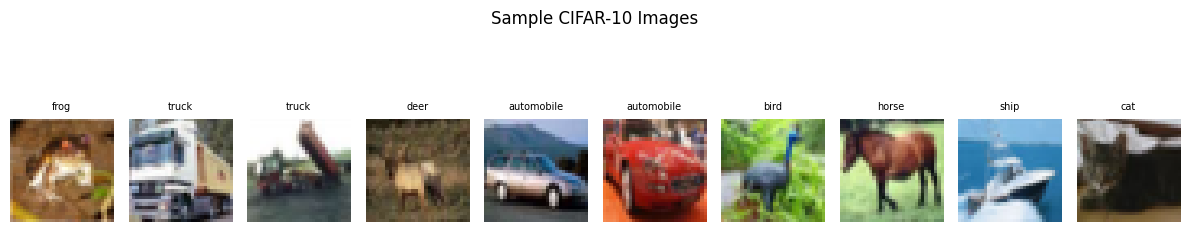

Sample images saved.


In [2]:
# ── CELL 2 — Load & Preprocess Data ──────────────────────────
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize pixel values to [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test  = x_test.astype('float32')  / 255.0

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test,  10)

# Class names for display
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print(f"Train: {x_train.shape} | Test: {x_test.shape}")

# Preview a few images
plt.figure(figsize=(12, 3))
for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(x_train[i])
    plt.title(CLASS_NAMES[y_train[i][0]], fontsize=7)
    plt.axis('off')
plt.suptitle("Sample CIFAR-10 Images")
plt.tight_layout()
plt.savefig('sample_images.png', dpi=100)
plt.show()
print("Sample images saved.")


In [3]:
# ── CELL 3 — Data Augmentation ────────────────────────────────
# Augmentation makes the model more robust by showing
# slightly modified versions of training images each epoch
datagen = ImageDataGenerator(
    rotation_range=15,          # randomly rotate images ±15 degrees
    width_shift_range=0.1,      # randomly shift horizontally
    height_shift_range=0.1,     # randomly shift vertically
    horizontal_flip=True,       # randomly flip left-right
    zoom_range=0.1,             # randomly zoom in/out
    fill_mode='nearest'
)

datagen.fit(x_train)
print("Data augmentation configured.")

Data augmentation configured.


In [4]:
# ── CELL 4 — Build Model ──────────────────────────────────────
def build_model():
    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.2),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(64, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.3),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(128, (3,3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),
        layers.Dropout(0.4),

        # Classifier head
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()

# Count parameters
total_params = model.count_params()
print(f"\nTotal parameters: {total_params:,}")



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,345,066 (5.13 MB)

 Trainable params: 1,343,146 (5.12 MB)

 Non-trainable params: 1,920 (7.50 KB)


Total parameters: 1,345,066


In [5]:
# ── CELL 5 — Callbacks ────────────────────────────────────────
callbacks = [
    # Save best model automatically
    ModelCheckpoint(
        'best_cifar10_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Stop early if no improvement for 10 epochs
    EarlyStopping(
        monitor='val_accuracy',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce learning rate when stuck
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print("Callbacks configured:")
print("  ✓ ModelCheckpoint — saves best model")
print("  ✓ EarlyStopping   — stops if no improvement for 10 epochs")
print("  ✓ ReduceLROnPlateau — halves LR if stuck for 5 epochs")


Callbacks configured:
  ✓ ModelCheckpoint — saves best model
  ✓ EarlyStopping   — stops if no improvement for 10 epochs
  ✓ ReduceLROnPlateau — halves LR if stuck for 5 epochs


In [6]:
# ── CELL 6 — Train ────────────────────────────────────────────
EPOCHS = 50
BATCH_SIZE = 64

print(f"\nStarting training: {EPOCHS} epochs, batch size {BATCH_SIZE}")
print("Leave this running overnight on GPU!\n")

history = model.fit(
    datagen.flow(x_train, y_train_cat, batch_size=BATCH_SIZE),
    steps_per_epoch=len(x_train) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_test, y_test_cat),
    callbacks=callbacks,
    verbose=1
)

print("\nTraining complete!")



Starting training: 50 epochs, batch size 64
Leave this running overnight on GPU!

Epoch 1/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.3279 - loss: 2.1685
Epoch 1: val_accuracy improved from None to 0.49770, saving model to best_cifar10_model.h5



Epoch 1: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 59s 58ms/step - accuracy: 0.4043 - loss: 1.7726 - val_accuracy: 0.4977 - val_loss: 1.4586 - learning_rate: 0.0010
Epoch 2/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 12s 15ms/step - accuracy: 0.4531 - loss: 1.3501

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_accuracy improved from 0.49770 to 0.51420, saving model to best_cifar10_model.h5



Epoch 2: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4531 - loss: 1.3501 - val_accuracy: 0.5142 - val_loss: 1.4124 - learning_rate: 0.0010
Epoch 3/50
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5361 - loss: 1.3005
Epoch 3: val_accuracy improved from 0.51420 to 0.55150, saving model to best_cifar10_model.h5


...


Epoch 31: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8143 - loss: 0.5375 - val_accuracy: 0.8356 - val_loss: 0.4975 - learning_rate: 5.0000e-04
Epoch 32/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8281 - loss: 0.4144
Epoch 32: val_accuracy did not improve from 0.83560
781/781 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8281 - loss: 0.4144 - val_accuracy: 0.8352 - val_loss: 0.4969 - learning_rate: 5.0000e-04
Epoch 33/50
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8162 - loss: 0.5249
Epoch 33: val_accuracy did not improve from 0.83560
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8183 - loss: 0.5233 - val_accuracy: 0.8309 - val_loss: 0.5031 - learning_rate: 5.0000e-04
Epoch 34/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.8125 - loss: 0.5426
Epoch 34: val_accuracy did not improve from 0.83560
781/781 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8125 - loss: 0.5426 - val_


Epoch 35: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8225 - loss: 0.5137 - val_accuracy: 0.8421 - val_loss: 0.4804 - learning_rate: 5.0000e-04
Epoch 36/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7969 - loss: 0.4666
Epoch 36: val_accuracy did not improve from 0.84210
781/781 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7969 - loss: 0.4666 - val_accuracy: 0.8414 - val_loss: 0.4821 - learning_rate: 5.0000e-04
Epoch 37/50
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8234 - loss: 0.5071
Epoch 37: val_accuracy improved from 0.84210 to 0.84310, saving model to best_cifar10_model.h5



Epoch 37: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8236 - loss: 0.5111 - val_accuracy: 0.8431 - val_loss: 0.4823 - learning_rate: 5.0000e-04
Epoch 38/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.7812 - loss: 0.4983
Epoch 38: val_accuracy did not improve from 0.84310
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7812 - loss: 0.4983 - val_accuracy: 0.8413 - val_loss: 0.4875 - learning_rate: 5.0000e-04
Epoch 39/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8257 - loss: 0.5008
Epoch 39: val_accuracy did not improve from 0.84310
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8251 - loss: 0.5032 - val_accuracy: 0.8295 - val_loss: 0.5000 - learning_rate: 5.0000e-04
Epoch 40/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8438 - loss: 0.4573
Epoch 40: val_accuracy did not improve from 0.84310
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8438 - loss: 0.4573 - val_


Epoch 42: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8438 - loss: 0.4792 - val_accuracy: 0.8439 - val_loss: 0.4684 - learning_rate: 5.0000e-04
Epoch 43/50
780/781 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8282 - loss: 0.4913
Epoch 43: val_accuracy did not improve from 0.84390
781/781 ━━━━━━━━━━━━━━━━━━━━ 39s 44ms/step - accuracy: 0.8306 - loss: 0.4900 - val_accuracy: 0.8425 - val_loss: 0.4702 - learning_rate: 5.0000e-04
Epoch 44/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.8125 - loss: 0.4988
Epoch 44: val_accuracy did not improve from 0.84390
781/781 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8125 - loss: 0.4988 - val_accuracy: 0.8416 - val_loss: 0.4726 - learning_rate: 5.0000e-04
Epoch 45/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8343 - loss: 0.4811
Epoch 45: val_accuracy improved from 0.84390 to 0.86070, saving model to best_cifar10_model.h5



Epoch 45: finished saving model to best_cifar10_model.h5
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 44ms/step - accuracy: 0.8327 - loss: 0.4858 - val_accuracy: 0.8607 - val_loss: 0.4242 - learning_rate: 5.0000e-04
Epoch 46/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.8750 - loss: 0.3686
Epoch 46: val_accuracy did not improve from 0.86070
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8750 - loss: 0.3686 - val_accuracy: 0.8600 - val_loss: 0.4266 - learning_rate: 5.0000e-04
Epoch 47/50
781/781 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.8372 - loss: 0.4695
Epoch 47: val_accuracy did not improve from 0.86070
781/781 ━━━━━━━━━━━━━━━━━━━━ 35s 45ms/step - accuracy: 0.8334 - loss: 0.4788 - val_accuracy: 0.8341 - val_loss: 0.5017 - learning_rate: 5.0000e-04
Epoch 48/50
  1/781 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.9531 - loss: 0.2200
Epoch 48: val_accuracy did not improve from 0.86070
781/781 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9531 - loss: 0.2200 - val_

In [7]:
# ── CELL 7 — Evaluate ─────────────────────────────────────────
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)

print("\n" + "="*50)
print("FINAL RESULTS")
print("="*50)
print(f"Test Accuracy:  {test_acc*100:.2f}%")
print(f"Test Loss:      {test_loss:.4f}")
print(f"Target (85%):   {'✅ ACHIEVED' if test_acc >= 0.85 else '❌ Not yet — try more epochs'}")
print("="*50)


FINAL RESULTS
Test Accuracy:  86.07%
Test Loss:      0.4242
Target (85%):   ✅ ACHIEVED


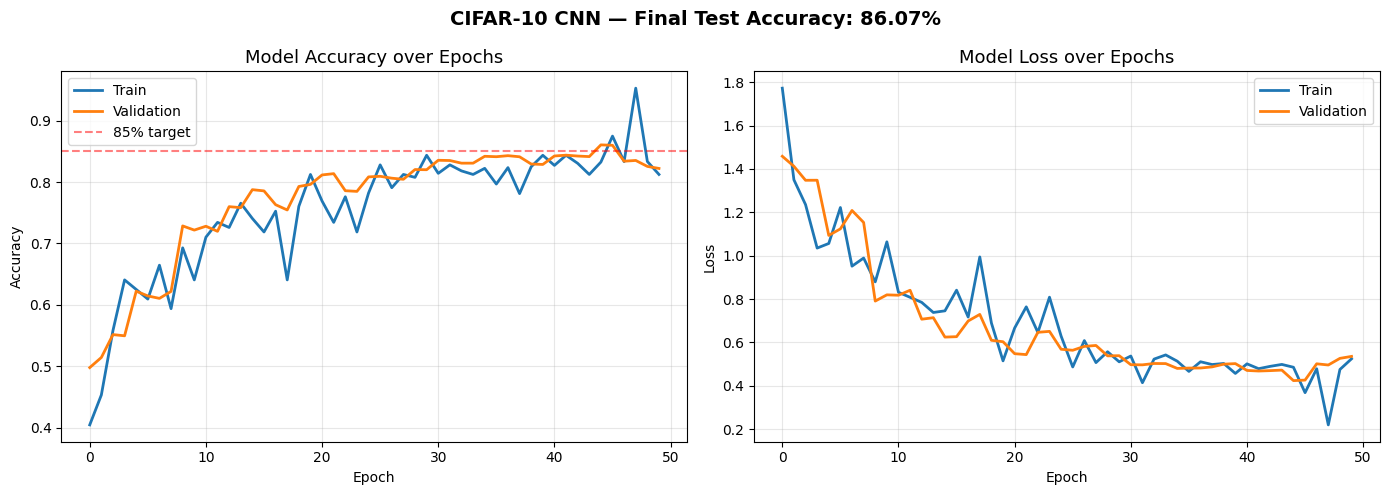

Training history plot saved.


In [8]:
# ── CELL 8 — Plot Training History ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_title('Model Accuracy over Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='85% target')
axes[0].legend()

# Loss plot
axes[1].plot(history.history['loss'],     label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_title('Model Loss over Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'CIFAR-10 CNN — Final Test Accuracy: {test_acc*100:.2f}%',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training history plot saved.")



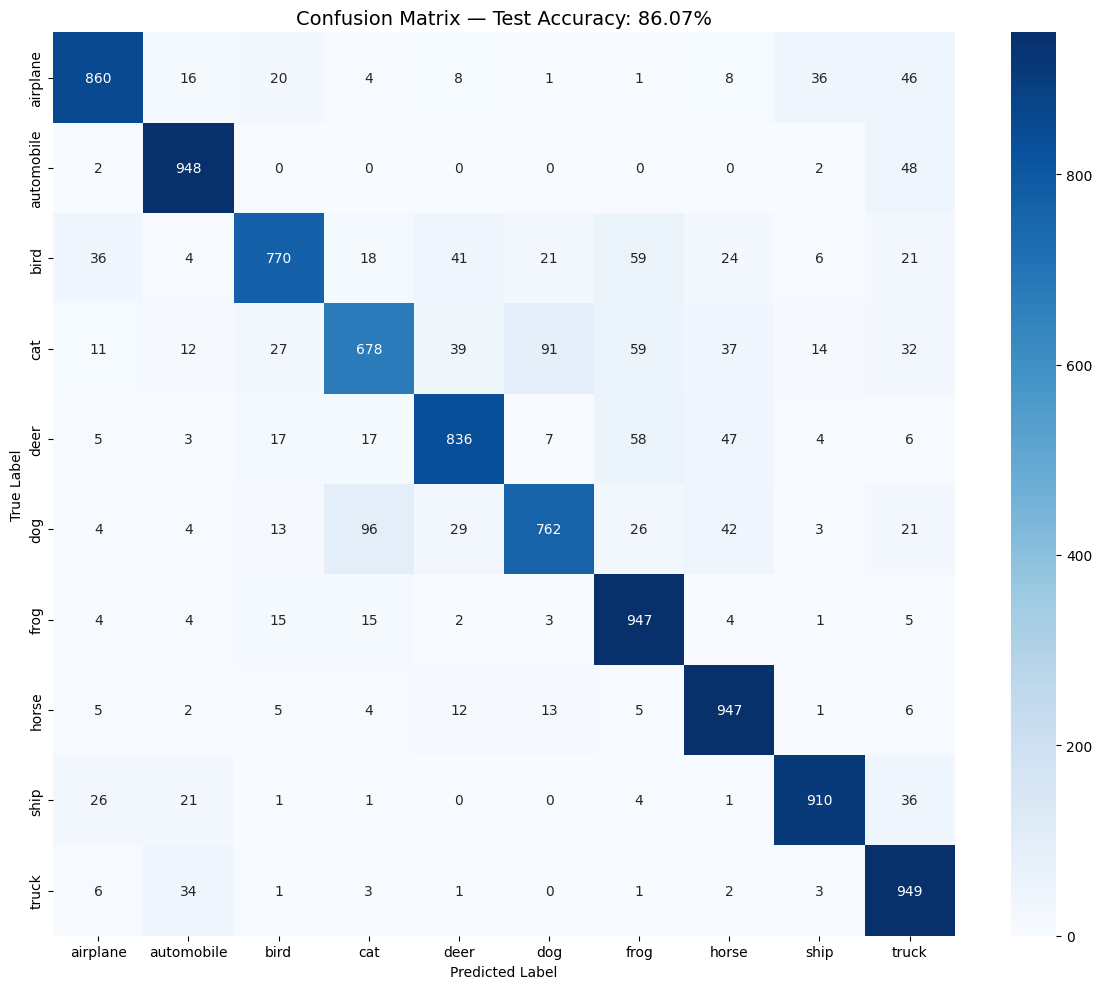


Per-class Report:
              precision    recall  f1-score   support

    airplane       0.90      0.86      0.88      1000
  automobile       0.90      0.95      0.93      1000
        bird       0.89      0.77      0.82      1000
         cat       0.81      0.68      0.74      1000
        deer       0.86      0.84      0.85      1000
         dog       0.85      0.76      0.80      1000
        frog       0.82      0.95      0.88      1000
       horse       0.85      0.95      0.90      1000
        ship       0.93      0.91      0.92      1000
       truck       0.81      0.95      0.87      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



In [9]:
# ── CELL 9 — Confusion Matrix ─────────────────────────────────
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_pred = model.predict(x_test, verbose=0)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = y_test.flatten()

# Confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES,
            yticklabels=CLASS_NAMES)
plt.title(f'Confusion Matrix — Test Accuracy: {test_acc*100:.2f}%', fontsize=14)
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# Per-class accuracy
print("\nPer-class Report:")
print(classification_report(y_true_classes, y_pred_classes,
                            target_names=CLASS_NAMES))



In [10]:
# ── CELL 10 — Experiment Summary (copy to README) ─────────────
best_val_acc = max(history.history['val_accuracy'])
best_epoch   = history.history['val_accuracy'].index(best_val_acc) + 1
epochs_run   = len(history.history['accuracy'])

print("""
╔══════════════════════════════════════════════════════════╗
║           EXPERIMENT SUMMARY — CIFAR-10 CNN              ║
╠══════════════════════════════════════════════════════════╣
║  Architecture                                            ║
║  ├─ 3 Conv blocks (32 → 64 → 128 filters)               ║
║  ├─ BatchNormalization after each Conv layer             ║
║  ├─ MaxPooling + Dropout (0.2 → 0.3 → 0.4)              ║
║  └─ Dense(512) → Dropout(0.5) → Softmax(10)             ║
╠══════════════════════════════════════════════════════════╣
║  Training Config                                         ║
║  ├─ Optimizer: Adam (lr=0.001, ReduceLROnPlateau)        ║
║  ├─ Loss: Categorical Crossentropy                       ║
║  ├─ Batch size: 64                                       ║
║  └─ Data augmentation: flip, rotate, shift, zoom        ║
╠══════════════════════════════════════════════════════════╣""")

print(f"║  Results                                                 ║")
print(f"║  ├─ Epochs run:        {epochs_run:<34}║")
print(f"║  ├─ Best val accuracy: {best_val_acc*100:.2f}% (epoch {best_epoch})               ║")
print(f"║  └─ Final test acc:    {test_acc*100:.2f}%                              ║")
print("╚══════════════════════════════════════════════════════════╝")



╔══════════════════════════════════════════════════════════╗
║           EXPERIMENT SUMMARY — CIFAR-10 CNN              ║
╠══════════════════════════════════════════════════════════╣
║  Architecture                                            ║
║  ├─ 3 Conv blocks (32 → 64 → 128 filters)               ║
║  ├─ BatchNormalization after each Conv layer             ║
║  ├─ MaxPooling + Dropout (0.2 → 0.3 → 0.4)              ║
║  └─ Dense(512) → Dropout(0.5) → Softmax(10)             ║
╠══════════════════════════════════════════════════════════╣
║  Training Config                                         ║
║  ├─ Optimizer: Adam (lr=0.001, ReduceLROnPlateau)        ║
║  ├─ Loss: Categorical Crossentropy                       ║
║  ├─ Batch size: 64                                       ║
║  └─ Data augmentation: flip, rotate, shift, zoom        ║
╠══════════════════════════════════════════════════════════╣
║  Results                                                 ║
║  ├─ Epochs run:        50

In [11]:
# Download everything to your local machine
from google.colab import files

files.download('best_cifar10_model.h5')
files.download('training_history.png')
files.download('confusion_matrix.png')
files.download('sample_images.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>